In [26]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [27]:
import pandas as pd

#Load the metadata
metadata = pd.read_csv("data/annotations_combined_with_average.csv")

metadata=metadata[metadata["img_id"].notna()]
metadata.head(10)

metadata["hair_average"]=(
    metadata["hair_average"].astype(str)
    .str.replace(",", "." , regex=False)
    .astype(float)
)

In [28]:
metadata

,img_id,group_id,hair_average,pen_average,diagnostic
0,PAT_100_393_898.png,a,0.75,0.25,NEV
1,PAT_1065_278_954.png,a,0.00,1.00,ACK
2,PAT_1066_281_99.png,a,1.00,1.00,ACK
3,PAT_1070_304_845.png,a,1.00,0.00,ACK
4,PAT_1089_375_677.png,a,0.75,0.25,NEV
...,...,...,...,...,...
1631,PAT_93_361_467.png,r,2.20,0.00,SEK
1632,PAT_946_1809_687.png,r,0.00,0.00,BCC
1633,PAT_961_1818_992.png,r,2.00,0.00,ACK
1634,PAT_966_1825_584.png,r,1.80,0.00,MEL


In [29]:
def hair_coverage(img_gray):

    # generate hair mask using BlackHat filtering
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    total_area = img_gray.shape[0] * img_gray.shape[1]
    hair_area = np.sum(hair_mask > 0)
    coverage = hair_area / total_area
    
    return round(coverage, 4)

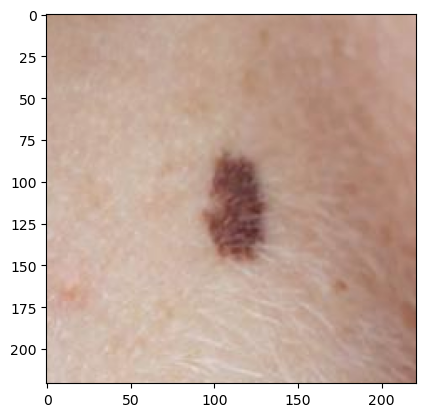

In [30]:
img_id = metadata["img_id"][0]
img_path = (f"data/imgs/{img_id}")

img_org_hair = cv2.imread(img_path)

img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2RGB))

In [31]:
metadata["coverage_hair"] = 0

In [32]:
for patient in metadata.itertuples():
    img_id = patient.img_id
    img_path = (f"data/imgs/{img_id}")

    img_org_hair = cv2.imread(img_path)
    img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)

    coverage_hair = hair_coverage(img_gray_hair)
    metadata.loc[metadata["img_id"]== img_id, "coverage_hair"] = coverage_hair


/var/folders/yc/hj112b594w727n5n4pblx23m0000gn/T/ipykernel_10634/1504730911.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0083' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  metadata.loc[metadata["img_id"]== img_id, "coverage_hair"] = coverage_hair


In [36]:
metadata.head(50)

,img_id,group_id,hair_average,pen_average,diagnostic,coverage_hair
0,PAT_100_393_898.png,a,0.75,0.25,NEV,0.0083
1,PAT_1065_278_954.png,a,0.00,1.00,ACK,0.0490
2,PAT_1066_281_99.png,a,1.00,1.00,ACK,0.0891
3,PAT_1070_304_845.png,a,1.00,0.00,ACK,0.0042
4,PAT_1089_375_677.png,a,0.75,0.25,NEV,0.0078
5,PAT_115_176_455.png,a,0.25,0.25,BCC,0.0735
6,PAT_119_181_684.png,a,0.00,0.25,BCC,0.0065
7,PAT_1243_837_806.png,a,1.00,1.00,ACK,0.0086
8,PAT_1249_861_810.png,a,1.50,0.25,ACK,0.0134
9,PAT_1255_876_939.png,a,0.00,0.25,ACK,0.0008


In [38]:
metadata.to_csv("annotations_combined_with_average.csv", index=False)

In [ ]:
# metadata["hair_average"] = metadata["hair_average"].apply(lambda x: round(float(x)*2)/2)

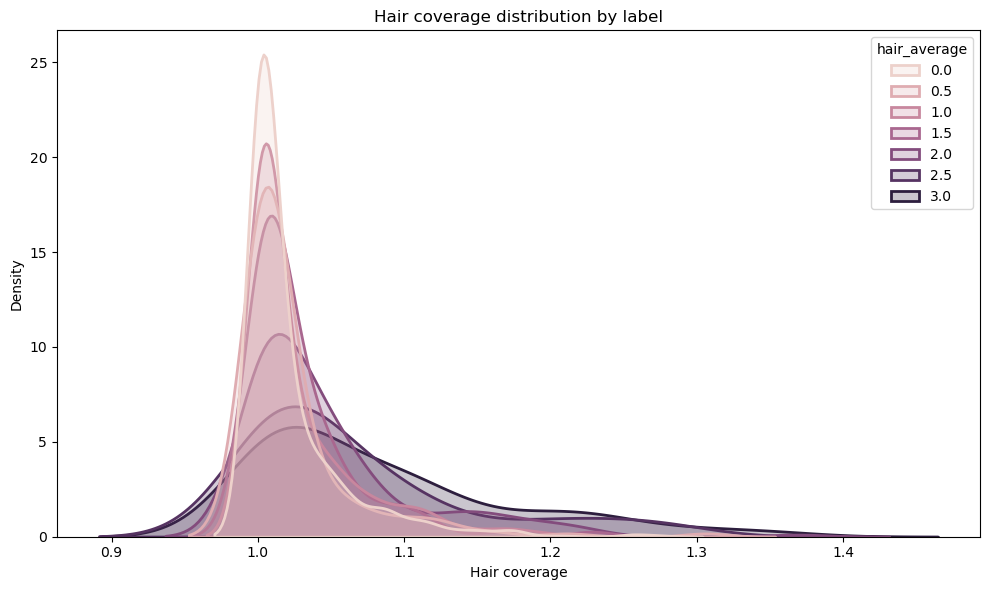

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=metadata,
    x="coverage_hair",
    hue="hair_average",          
    fill=True,
    common_norm=False,
    linewidth=2
)

plt.xlabel("Hair coverage")
plt.ylabel("Density")
plt.title("Hair coverage distribution by label")

plt.tight_layout()
plt.show()
